# Example1) PCA 2D to 1D

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# Create 2D dataset


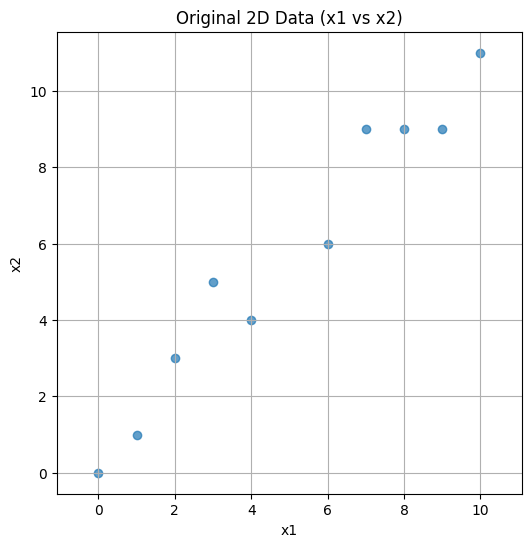

In [2]:
np.random.seed(42)
n_samples = 10

# Create data along x1 ≈ x2 with some noise
x = np.linspace(0, 10, n_samples)
x = np.round(x).astype(int)

y = x + np.random.normal(0, 1, n_samples)
y = np.round(y).astype(int)

X = np.column_stack((x, y))  # shape (100, 2)

# Plot original data
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.7)
plt.title("Original 2D Data (x1 vs x2)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis('equal')
plt.grid(True)
plt.show()


# Step 1: Standardize the data


In [3]:
X_mean = np.mean(X, axis=0)
print("X_mean:\n", X_mean) # (mean_of_col1, mean_of_col2)

X_std = np.std(X, axis=0)
print("\nX_std:\n", X_std) # # (mstd_of_col1, std_of_col2)

X_scaled = (X - X_mean) / X_std

print("\nStandardized Data:\n", X_scaled)

X_mean:
 [5.  5.7]

X_std:
 [3.31662479 3.55105618]

Standardized Data:
 [[-1.50755672 -1.60515624]
 [-1.20604538 -1.32354989]
 [-0.90453403 -0.76033717]
 [-0.60302269 -0.19712445]
 [-0.30151134 -0.47873081]
 [ 0.30151134  0.08448191]
 [ 0.60302269  0.92930098]
 [ 0.90453403  0.92930098]
 [ 1.20604538  0.92930098]
 [ 1.50755672  1.4925137 ]]


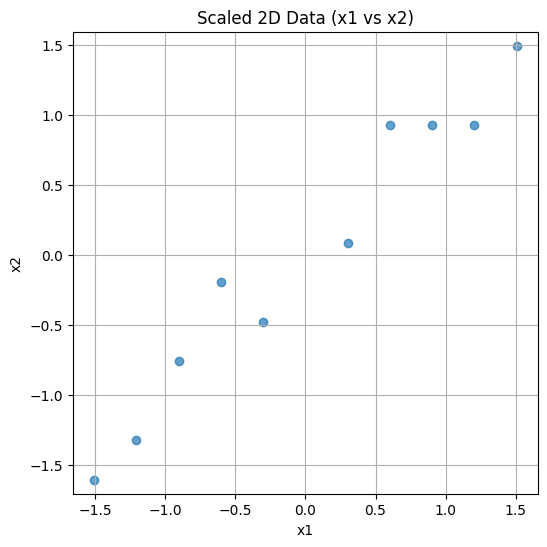

In [14]:
# Plot original data
plt.figure(figsize=(6, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], alpha=0.7)
plt.title("Scaled 2D Data (x1 vs x2)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis('equal')
plt.grid(True)
plt.show()

# Step 2: Compute Covariance Matrix

In [4]:
cov_matrix = np.cov(X_scaled.T)
print("\nCovariance Matrix:\n", cov_matrix)


Covariance Matrix:
 [[1.11111111 1.08492932]
 [1.08492932 1.11111111]]


# Step 3: Compute Eigenvalues and Eigenvectors

In [5]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("\nEigenvalues:\n", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)


Eigenvalues:
 [2.19604043 0.02618179]

Eigenvectors:
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


# Step 4: Sort Eigenvalues and Select Top k=1

In [6]:

sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[sorted_indices]
eigenvectors_sorted = eigenvectors[:, sorted_indices]

print("\nSorted Eigenvalues:\n", eigenvalues_sorted)
print("\nSorted Eigenvectors:\n", eigenvectors_sorted)


Sorted Eigenvalues:
 [2.19604043 0.02618179]

Sorted Eigenvectors:
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


# Step 5: Project Data to 1D

In [7]:

k=1
W = eigenvectors_sorted[:, :k]  # Top-1 component
print(f"\nProjection Matrix W (top {k} eigenvectors):\n", W)
X_pca = X_scaled @ W  # shape (100, 1)


Projection Matrix W (top 1 eigenvectors):
 [[0.70710678]
 [0.70710678]]


In [8]:
print("Original points:\n", X )
print("\nScaled points:\n", X_scaled )
print("\nPoints on PC1:\n", X_pca)

Original points:
 [[ 0  0]
 [ 1  1]
 [ 2  3]
 [ 3  5]
 [ 4  4]
 [ 6  6]
 [ 7  9]
 [ 8  9]
 [ 9  9]
 [10 11]]

Scaled points:
 [[-1.50755672 -1.60515624]
 [-1.20604538 -1.32354989]
 [-0.90453403 -0.76033717]
 [-0.60302269 -0.19712445]
 [-0.30151134 -0.47873081]
 [ 0.30151134  0.08448191]
 [ 0.60302269  0.92930098]
 [ 0.90453403  0.92930098]
 [ 1.20604538  0.92930098]
 [ 1.50755672  1.4925137 ]]

Points on PC1:
 [[-2.20102045]
 [-1.78869396]
 [-1.17724172]
 [-0.56578947]
 [-0.55171452]
 [ 0.27293845]
 [ 1.08351646]
 [ 1.29671718]
 [ 1.50991789]
 [ 2.12137014]]


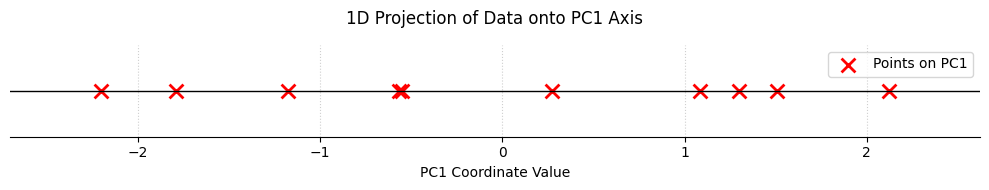

In [15]:
# Lets the points on PC1

# Create an array of zeros for the y-axis
y_zeros = np.zeros_like(X_pca)

# 2. Plotting
plt.figure(figsize=(10, 2))  # Short height to emphasize 1D space

# Plot points on the line
plt.scatter(X_pca, y_zeros, color='red', marker='x', s=100, linewidths=2, label='Points on PC1')

# Draw the single axis line
plt.axhline(0, color='black', linewidth=1)

# Aesthetics
plt.title('1D Projection of Data onto PC1 Axis', fontsize=12, pad=15)
plt.xlabel('PC1 Coordinate Value', fontsize=10)
plt.grid(axis='x', linestyle=':', alpha=0.6)

# Hide the y-axis entirely since it has no meaning here
plt.gca().get_yaxis().set_visible(False)

# Clean up borders
for spine in ['top', 'left', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.xlim(min(X_pca) - 0.5, max(X_pca) + 0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


## Step 6: Reconstruct to Original 2D Space

In [16]:

X_reconstructed = X_pca @ W.T  # shape (100, 2)
X_reconstructed = X_reconstructed * X_std + X_mean  # unscale

top_n=10
print("\nReconstructed Data (Approximate Original):\n", X_reconstructed[:top_n])
print("Actual data:\n",X[:top_n])



Reconstructed Data (Approximate Original):
 [[-0.16185049  0.17329069]
 [ 0.80514082  1.20863255]
 [ 2.23912345  2.74397441]
 [ 3.67310608  4.27931628]
 [ 3.70611476  4.31465814]
 [ 5.64009739  6.38534186]
 [ 7.54107134  8.42068372]
 [ 8.04107134  8.95602559]
 [ 8.54107134  9.49136745]
 [ 9.97505397 11.02670931]]
Actual data:
 [[ 0  0]
 [ 1  1]
 [ 2  3]
 [ 3  5]
 [ 4  4]
 [ 6  6]
 [ 7  9]
 [ 8  9]
 [ 9  9]
 [10 11]]


# Step 7: Plot Reconstructed vs Original


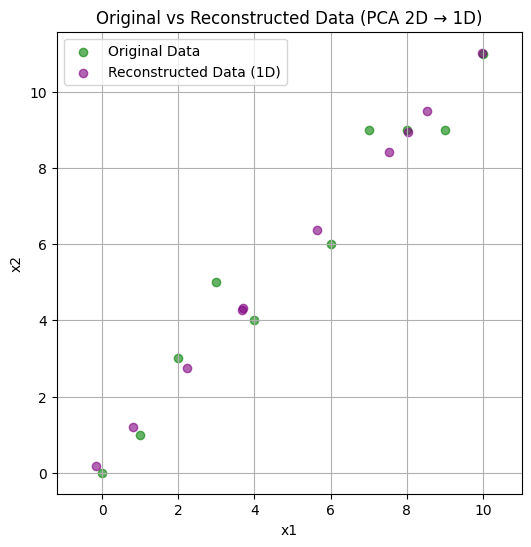


Original Data (first 5 rows):
 [[0 0]
 [1 1]
 [2 3]
 [3 5]
 [4 4]]

Reconstructed Data (first 5 rows):
 [[-0.16185049  0.17329069]
 [ 0.80514082  1.20863255]
 [ 2.23912345  2.74397441]
 [ 3.67310608  4.27931628]
 [ 3.70611476  4.31465814]]


In [17]:

# Assuming X (original data) and X_reconstructed are already defined

plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], color='green', alpha=0.6, label='Original Data')
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], color='purple', alpha=0.6, label='Reconstructed Data (1D)')
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Original vs Reconstructed Data (PCA 2D → 1D)")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

# Optional: Print a few samples to compare
print("\nOriginal Data (first 5 rows):\n", X[:5])
print("\nReconstructed Data (first 5 rows):\n", X_reconstructed[:5])

# Prettify this

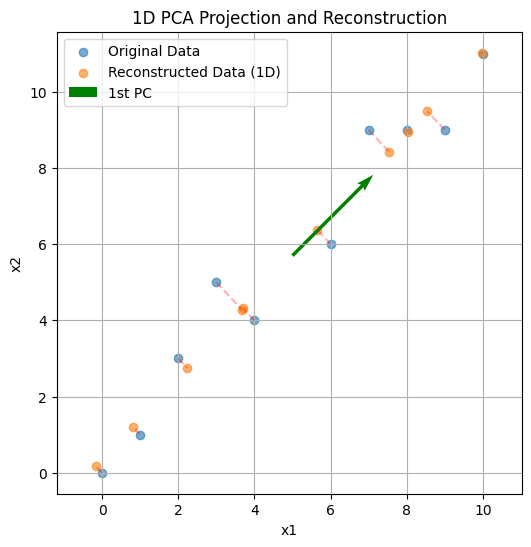

Explained Variance by 1st PC: 98.82%


In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X[:, 0], X[:, 1], alpha=0.6, label='Original Data')
ax.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], alpha=0.6, label='Reconstructed Data (1D)')
for i in range(n_samples):
    ax.plot([X[i, 0], X_reconstructed[i, 0]],
            [X[i, 1], X_reconstructed[i, 1]],
            'r--', alpha=0.3)

# Draw first principal component vector
origin = X_mean
pc1_vector = eigenvectors_sorted[:, 0] * 3  # scaled for visualization
ax.quiver(*origin, *pc1_vector, angles='xy', scale_units='xy', scale=1, color='green', label='1st PC')

ax.set_title("1D PCA Projection and Reconstruction")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.axis('equal')
ax.grid(True)
ax.legend()
plt.show()

# --------------------------
# Explained Variance
# --------------------------
explained_variance_ratio = eigenvalues_sorted[0] / np.sum(eigenvalues_sorted)
print(f"Explained Variance by 1st PC: {explained_variance_ratio:.2%}")


# (OPTIONAL) Example 2) PCA: 3D to 2D

In [19]:
import numpy as np
import matplotlib.pyplot as plt

In [20]:
# Step 0: Create a sample 3D dataset (10 samples, 3 features)
np.random.seed(42)
X = np.random.rand(10, 3) * 10  # shape: (10, 3)
print("Actual data:\n",X)

Actual data:
 [[3.74540119 9.50714306 7.31993942]
 [5.98658484 1.5601864  1.5599452 ]
 [0.58083612 8.66176146 6.01115012]
 [7.08072578 0.20584494 9.69909852]
 [8.32442641 2.12339111 1.81824967]
 [1.8340451  3.04242243 5.24756432]
 [4.31945019 2.9122914  6.11852895]
 [1.39493861 2.92144649 3.66361843]
 [4.56069984 7.85175961 1.99673782]
 [5.14234438 5.92414569 0.46450413]]


In [21]:
# Step 1: Standardize the data
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_scaled = (X - X_mean) / X_std

print("Standardized Data:\n", X_scaled)

Standardized Data:
 [[-0.2326323   1.62952924  1.03975211]
 [ 0.71266246 -0.941863   -1.00425961]
 [-1.5673943   1.35598959  0.57531055]
 [ 1.17415329 -1.38008649  1.88402884]
 [ 1.69872596 -0.75962717 -0.91259679]
 [-1.03881117 -0.46225673  0.30434182]
 [ 0.00949222 -0.50436316  0.61341538]
 [-1.22401913 -0.50140085 -0.25774276]
 [ 0.11124739  1.09389776 -0.84925786]
 [ 0.35657559  0.47018082 -1.39299167]]


In [22]:
# Step 2: Compute covariance matrix (features as columns)
cov_matrix = np.cov(X_scaled.T)  # shape: (3, 3)
print("\nCovariance Matrix:\n", cov_matrix)


Covariance Matrix:
 [[ 1.11111111 -0.52311455 -0.19816258]
 [-0.52311455  1.11111111 -0.04348754]
 [-0.19816258 -0.04348754  1.11111111]]


In [23]:
# Step 3: Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("\nEigenvalues:\n", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)


Eigenvalues:
 [0.53622717 1.65728025 1.13982592]

Eigenvectors:
 [[-0.69686199 -0.71482051 -0.05843807]
 [-0.656033    0.66823293 -0.35083536]
 [-0.28983455  0.20614653  0.93461197]]


In [24]:
# Step 4: Sort eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[sorted_indices]
eigenvectors_sorted = eigenvectors[:, sorted_indices]

print("\nSorted Eigenvalues:\n", eigenvalues_sorted)
print("\nSorted Eigenvectors:\n", eigenvectors_sorted)


Sorted Eigenvalues:
 [1.65728025 1.13982592 0.53622717]

Sorted Eigenvectors:
 [[-0.71482051 -0.05843807 -0.69686199]
 [ 0.66823293 -0.35083536 -0.656033  ]
 [ 0.20614653  0.93461197 -0.28983455]]


In [25]:
# Step 5: Select top k eigenvectors (k=2 here)
k = 2
W = eigenvectors_sorted[:, :k]  # projection matrix (3x2)
print(f"\nProjection Matrix W (top {k} eigenvectors):\n", W)


Projection Matrix W (top 2 eigenvectors):
 [[-0.71482051 -0.05843807]
 [ 0.66823293 -0.35083536]
 [ 0.20614653  0.93461197]]


In [26]:
# Step 6: Transform data to new subspace
X_pca = X_scaled @ W  # shape: (10, 2)
print("\nTransformed Data (Reduced to 2D):\n", X_pca)


Transformed Data (Reduced to 2D):
 [[ 1.46953672  0.41366288]
 [-1.34583425 -0.64980084]
 [ 2.14512076  0.15355853]
 [-1.3731421   2.1764038 ]
 [-1.9100207  -0.68569008]
 [ 0.49640736  0.50732363]
 [-0.21736385  0.74969908]
 [ 0.48676864  0.00654899]
 [ 0.47638503 -1.18400566]
 [-0.22785763 -1.48770034]]



Reconstructed Data (Approximate Original):
 [[ 1.74912603  7.05739383  6.33308691]
 [ 6.66783581  2.39619042  1.89671953]
 [ 0.6402133   8.73462676  6.04050304]
 [ 6.32254574 -0.72456336  9.32429454]
 [ 7.62896668  1.26995066  1.47445128]
 [ 3.38536625  4.94614186  6.01445518]
 [ 4.56145326  3.20926793  6.23816243]
 [ 3.47108378  5.46920902  4.68995444]
 [ 3.65363262  6.7386429   1.54833192]
 [ 4.88922899  5.61353258  0.33937731]]
Actual data:
 [[3.74540119 9.50714306 7.31993942]
 [5.98658484 1.5601864  1.5599452 ]
 [0.58083612 8.66176146 6.01115012]
 [7.08072578 0.20584494 9.69909852]
 [8.32442641 2.12339111 1.81824967]
 [1.8340451  3.04242243 5.24756432]
 [4.31945019 2.9122914  6.11852895]
 [1.39493861 2.92144649 3.66361843]
 [4.56069984 7.85175961 1.99673782]
 [5.14234438 5.92414569 0.46450413]]


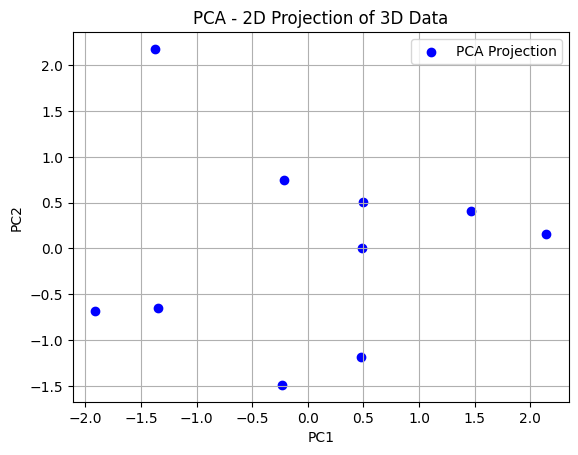

In [27]:
# Step 7 (Optional): Reconstruct original data (approximate)
X_reconstructed = X_pca @ W.T  # shape: (10, 3)
X_reconstructed = (X_reconstructed * X_std) + X_mean  # reverse standardization
print("\nReconstructed Data (Approximate Original):\n", X_reconstructed)
print("Actual data:\n",X)


# Optional: Visualize the 2D projection
plt.scatter(X_pca[:, 0], X_pca[:, 1], color='blue', label='PCA Projection')
plt.title("PCA - 2D Projection of 3D Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.legend()
plt.show()


In [28]:
# Analysis
explained_ratio = np.sum(eigenvalues_sorted[:k]) / np.sum(eigenvalues_sorted)
print(f"Explained Variance Ratio: {explained_ratio:.4f}")

Explained Variance Ratio: 0.8391
